# Imports

In [1]:
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

print("Base imports loaded successfully.")

Base imports loaded successfully.


In [2]:
from src.data_and_annotation import (
    prepare_part2_data,
    label_distribution,
    topic_distribution
)

from src.datasets import (
    load_word2idx,
    load_embeddings,
    build_model_vocab,
    SequenceTaggingDataset,
    make_collate_fn,
    PAD_TOKEN,
    UNK_TOKEN,
    PAD_LABEL
)

from src.models import (
    POSTagger,
    NERSoftmaxTagger,
    NERCRFTagger
)

from src.train_eval import (
    train_sequence_tagger,
    evaluate_sequence_tagger,
    plot_training_history,
    get_confusion_matrix,
    get_most_confused_pairs,
    collect_confusion_examples
)

print("All src imports loaded successfully.")

All src imports loaded successfully.


In [3]:
BASE_DIR = "."
CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
META_PATH = os.path.join(BASE_DIR, "metadata.json")
WORD2IDX_PATH = os.path.join(BASE_DIR, "word2idx.json")
EMB_PATH = os.path.join(BASE_DIR, "embeddings_w2v.npy")
DATA_DIR = os.path.join(BASE_DIR, "data")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Paths configured successfully.")
print("Using device:", DEVICE)

Paths configured successfully.
Using device: cuda


In [4]:
import src.data_and_annotation
import src.datasets
import src.crf
import src.models
import src.train_eval

print("data_and_annotation:", src.data_and_annotation.__file__)
print("datasets:", src.datasets.__file__)
print("crf:", src.crf.__file__)
print("models:", src.models.__file__)
print("train_eval:", src.train_eval.__file__)

from src.models import NERCRFTagger
print("NERCRFTagger imported successfully.")

data_and_annotation: c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER\src\data_and_annotation.py
datasets: c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER\src\datasets.py
crf: c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER\src\crf.py
models: c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER\src\models.py
train_eval: c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER\src\train_eval.py
NERCRFTagger imported successfully.


In [5]:
import importlib
import src.data_and_annotation

importlib.reload(src.data_and_annotation)

from src.data_and_annotation import prepare_part2_data

print("Reloaded data_and_annotation successfully.")
print(src.data_and_annotation.__file__)
print("load_articles exists:", hasattr(src.data_and_annotation, "load_articles"))

Reloaded data_and_annotation successfully.
c:\DL_Env\Projects\NLP Assignment 2\Sequence Labeling POS Tagging & NER\src\data_and_annotation.py
load_articles exists: True


In [6]:
import importlib
import src.train_eval

importlib.reload(src.train_eval)

from src.train_eval import (
    train_sequence_tagger,
    evaluate_sequence_tagger,
    plot_training_history,
    get_confusion_matrix,
    get_most_confused_pairs,
    collect_confusion_examples,
    train_crf_sequence_tagger,
    evaluate_crf_sequence_tagger,
    compute_entity_level_metrics,
    predict_softmax_sequences,
    predict_crf_sequences,
    collect_ner_error_examples
)

print("train_eval reloaded successfully.")

train_eval reloaded successfully.


## Part 2 data preparation

In [7]:
bundle = prepare_part2_data(
    cleaned_path=CLEANED_PATH,
    metadata_path=META_PATH,
    data_dir=DATA_DIR,
    target_size=500
)

articles = bundle["articles"]
selected_df = bundle["selected_df"]
annotated_examples = bundle["annotated_examples"]
train_data = bundle["train_data"]
val_data = bundle["val_data"]
test_data = bundle["test_data"]

pos2idx = bundle["pos2idx"]
idx2pos = bundle["idx2pos"]
ner2idx = bundle["ner2idx"]
idx2ner = bundle["idx2ner"]

print("Part 2A data preparation completed.")
print("Selected sentences:", len(annotated_examples))
print("Train / Val / Test:", len(train_data), len(val_data), len(test_data))

Part 2A data preparation completed.
Selected sentences: 500
Train / Val / Test: 350 75 75


## Topic distribution

In [8]:
print("Selected sentence topic distribution:")
display(selected_df["topic"].value_counts().to_frame("count"))

print("\nTrain topic distribution:")
display(topic_distribution(train_data).to_frame("count"))

print("\nValidation topic distribution:")
display(topic_distribution(val_data).to_frame("count"))

print("\nTest topic distribution:")
display(topic_distribution(test_data).to_frame("count"))

Selected sentence topic distribution:


,count
topic,
politics,202
health_society,107
economy,92
international,66
sports,33



Train topic distribution:


,count
politics,142
health_society,75
economy,64
international,46
sports,23



Validation topic distribution:


,count
politics,30
health_society,16
economy,14
international,10
sports,5



Test topic distribution:


,count
politics,30
health_society,16
economy,14
international,10
sports,5


## POS and NER label distributions

In [9]:
print("POS label distribution (all selected data):")
display(label_distribution(annotated_examples, task="pos").to_frame("count"))

print("\nNER label distribution (all selected data):")
display(label_distribution(annotated_examples, task="ner").to_frame("count"))

POS label distribution (all selected data):


,count
NOUN,6759
POST,1949
ADJ,1013
VERB,876
PRON,874
CONJ,505
DET,149
NUM,144
ADV,91
UNK,31



NER label distribution (all selected data):


,count
O,11670
B-LOC,290
B-ORG,196
B-PER,116
I-ORG,67
I-PER,36
I-LOC,15
B-MISC,8


## Preview annotations

In [10]:


sample = annotated_examples[0]
preview_rows = []

for tok, pos, ner in zip(sample["tokens"], sample["pos_tags"], sample["ner_tags"]):
    preview_rows.append({
        "token": tok,
        "pos": pos,
        "ner": ner
    })

print("Sample annotation preview:")
display(pd.DataFrame(preview_rows))

Sample annotation preview:


,token,pos,ner
0,وہ,PRON,O
1,جماعت,NOUN,O
2,کے,POST,O
3,قائد,NOUN,O
4,رہے,VERB,O
5,اور,CONJ,O
6,اب,ADV,O
7,صدر,NOUN,O
8,ہیں,VERB,O
9,اور,CONJ,O


## saved CoNLL files

In [11]:
required_files = [
    os.path.join(DATA_DIR, "pos_train.conll"),
    os.path.join(DATA_DIR, "pos_test.conll"),
    os.path.join(DATA_DIR, "ner_train.conll"),
    os.path.join(DATA_DIR, "ner_test.conll"),
]

for f in required_files:
    print(f, "FOUND" if os.path.exists(f) else "MISSING")

.\data\pos_train.conll FOUND
.\data\pos_test.conll FOUND
.\data\ner_train.conll FOUND
.\data\ner_test.conll FOUND


# Import dataset utilities

## Loading Part 1 vocabulary and embeddings

In [12]:
base_word2idx = load_word2idx(WORD2IDX_PATH)
base_embeddings = load_embeddings(EMB_PATH)

word2idx, idx2word, embedding_matrix = build_model_vocab(base_word2idx, base_embeddings)

print("Original embedding matrix shape :", base_embeddings.shape)
print("Expanded embedding matrix shape :", embedding_matrix.shape)
print("Vocabulary size with PAD        :", len(word2idx))
print("PAD token id                    :", word2idx[PAD_TOKEN])
print("UNK token id                    :", word2idx[UNK_TOKEN])

Original embedding matrix shape : (4387, 100)
Expanded embedding matrix shape : (4388, 100)
Vocabulary size with PAD        : 4388
PAD token id                    : 0
UNK token id                    : 1


## Build POS and NER datasets

In [13]:
pos_train_dataset = SequenceTaggingDataset(train_data, word2idx, pos2idx, task="pos")
pos_val_dataset = SequenceTaggingDataset(val_data, word2idx, pos2idx, task="pos")
pos_test_dataset = SequenceTaggingDataset(test_data, word2idx, pos2idx, task="pos")

ner_train_dataset = SequenceTaggingDataset(train_data, word2idx, ner2idx, task="ner")
ner_val_dataset = SequenceTaggingDataset(val_data, word2idx, ner2idx, task="ner")
ner_test_dataset = SequenceTaggingDataset(test_data, word2idx, ner2idx, task="ner")

print("POS train/val/test sizes:", len(pos_train_dataset), len(pos_val_dataset), len(pos_test_dataset))
print("NER train/val/test sizes:", len(ner_train_dataset), len(ner_val_dataset), len(ner_test_dataset))

POS train/val/test sizes: 350 75 75
NER train/val/test sizes: 350 75 75


## Build dataloaders

In [14]:
BATCH_SIZE = 32
collate_fn = make_collate_fn(pad_token_id=word2idx[PAD_TOKEN])

pos_train_loader = DataLoader(pos_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
pos_val_loader = DataLoader(pos_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
pos_test_loader = DataLoader(pos_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

ner_train_loader = DataLoader(ner_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
ner_val_loader = DataLoader(ner_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
ner_test_loader = DataLoader(ner_test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Dataloaders created successfully.")

Dataloaders created successfully.


## Inspect one POS batch

In [15]:
batch = next(iter(pos_train_loader))

print("POS batch shapes")
print("input_ids      :", batch["input_ids"].shape)
print("label_ids      :", batch["label_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("lengths        :", batch["lengths"].shape)

print("\nFirst sequence tokens:")
print(batch["tokens"][0])

print("\nFirst sequence POS labels:")
print(batch["labels"][0])

POS batch shapes
input_ids      : torch.Size([32, 39])
label_ids      : torch.Size([32, 39])
attention_mask : torch.Size([32, 39])
lengths        : torch.Size([32])

First sequence tokens:
['جرمانے', 'کی', 'عدم', 'ادائیگی', 'کی', 'صورت', 'میں', 'ملزم', 'کو', 'چھ', 'ماہ', 'کی', 'مزید', 'قید', 'کاٹ', 'پڑے', 'گی۔']

First sequence POS labels:
['NOUN', 'POST', 'NOUN', 'VERB', 'POST', 'NOUN', 'PRON', 'NOUN', 'POST', 'NOUN', 'NOUN', 'POST', 'ADV', 'NOUN', 'NOUN', 'NOUN', 'NOUN']


## Inspect one NER batch

In [16]:
batch = next(iter(ner_train_loader))

print("NER batch shapes")
print("input_ids      :", batch["input_ids"].shape)
print("label_ids      :", batch["label_ids"].shape)
print("attention_mask :", batch["attention_mask"].shape)
print("lengths        :", batch["lengths"].shape)

print("\nFirst sequence tokens:")
print(batch["tokens"][0])

print("\nFirst sequence NER labels:")
print(batch["labels"][0])

NER batch shapes
input_ids      : torch.Size([32, 40])
label_ids      : torch.Size([32, 40])
attention_mask : torch.Size([32, 40])
lengths        : torch.Size([32])

First sequence tokens:
['یہ', 'تصاویر', 'ان', 'کے', '<NUM>', 'میں', 'ریلیز', 'ہونے', 'والے', 'ٹی', 'وی', 'ڈرامہ', 'سیریل', 'کلر', 'کی', 'تھی۔']

First sequence NER labels:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ORG', 'O', 'O', 'O', 'O', 'O', 'O']


## Save processed embedding matrix for reuse

In [17]:
np.save(os.path.join(BASE_DIR, "embedding_matrix_part2.npy"), embedding_matrix.astype(np.float32))
print("Saved embedding_matrix_part2.npy successfully.")

Saved embedding_matrix_part2.npy successfully.


## Convert embedding matrix to torch tensor

In [18]:
embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

VOCAB_SIZE = embedding_matrix.shape[0]
EMBED_DIM = embedding_matrix.shape[1]
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.5
PAD_IDX = word2idx["<PAD>"]

print("Embedding tensor prepared.")
print("Vocabulary size :", VOCAB_SIZE)
print("Embedding dim   :", EMBED_DIM)
print("Hidden dim      :", HIDDEN_DIM)
print("PAD idx         :", PAD_IDX)

Embedding tensor prepared.
Vocabulary size : 4388
Embedding dim   : 100
Hidden dim      : 128
PAD idx         : 0


## Instantiate POS model (frozen embeddings)

In [19]:
pos_model_frozen = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=True,
    random_init_embeddings=False,
).to(DEVICE)

print(pos_model_frozen)
print("POS frozen model created successfully.")

POSTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (classifier): Linear(in_features=256, out_features=11, bias=True)
)
POS frozen model created successfully.


## Instantiate POS model (fine-tuned embeddings)

In [20]:
pos_model_tuned = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print(pos_model_tuned)
print("POS fine-tuned model created successfully.")

POSTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (classifier): Linear(in_features=256, out_features=11, bias=True)
)
POS fine-tuned model created successfully.


## Instantiate NER softmax baseline model

In [21]:
ner_model_softmax = NERSoftmaxTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(ner2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print(ner_model_softmax)
print("NER softmax baseline model created successfully.")

NERSoftmaxTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (classifier): Linear(in_features=256, out_features=9, bias=True)
)
NER softmax baseline model created successfully.


## Sanity-check POS forward pass

In [22]:
batch = next(iter(pos_train_loader))

input_ids = batch["input_ids"].to(DEVICE)
lengths = batch["lengths"].to(DEVICE)

with torch.no_grad():
    logits = pos_model_frozen(input_ids, lengths)

print("POS forward pass successful.")
print("Input shape :", input_ids.shape)
print("Logits shape:", logits.shape)

POS forward pass successful.
Input shape : torch.Size([32, 39])
Logits shape: torch.Size([32, 39, 11])


## Sanity-check NER forward pass

In [23]:
batch = next(iter(ner_train_loader))

input_ids = batch["input_ids"].to(DEVICE)
lengths = batch["lengths"].to(DEVICE)

with torch.no_grad():
    emissions = ner_model_softmax(input_ids, lengths)

print("NER softmax forward pass successful.")
print("Input shape    :", input_ids.shape)
print("Emissions shape:", emissions.shape)

NER softmax forward pass successful.
Input shape    : torch.Size([32, 39])
Emissions shape: torch.Size([32, 39, 9])


## POS training config

In [24]:
POS_MAX_EPOCHS = 30
POS_PATIENCE = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

print("POS training configuration")
print("Max epochs   :", POS_MAX_EPOCHS)
print("Patience     :", POS_PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay :", WEIGHT_DECAY)

POS training configuration
Max epochs   : 30
Patience     : 5
Learning rate: 0.001
Weight decay : 0.0001


## Train POS model with frozen embeddings

In [25]:
pos_frozen_result = train_sequence_tagger(
    model=pos_model_frozen,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("Best frozen validation Macro-F1:", pos_frozen_result["best_val_f1"])
print("Best frozen epoch:", pos_frozen_result["best_epoch"])

Epoch 01 | train_loss=2.0780 | val_loss=1.7272 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.5957 | val_loss=1.5725 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5158 | val_loss=1.5411 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.4859 | val_loss=1.5106 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.4534 | val_loss=1.4767 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 06 | train_loss=1.3955 | val_loss=1.4018 | val_acc=0.5244 | val_macro_f1=0.0688
Early stopping triggered at epoch 6.
Best frozen validation Macro-F1: 0.06880058866813835
Best frozen epoch: 1


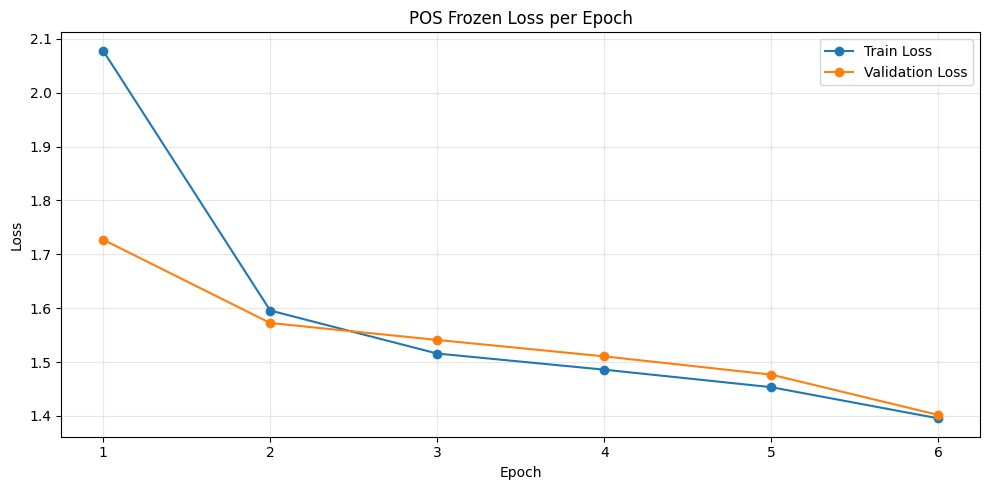

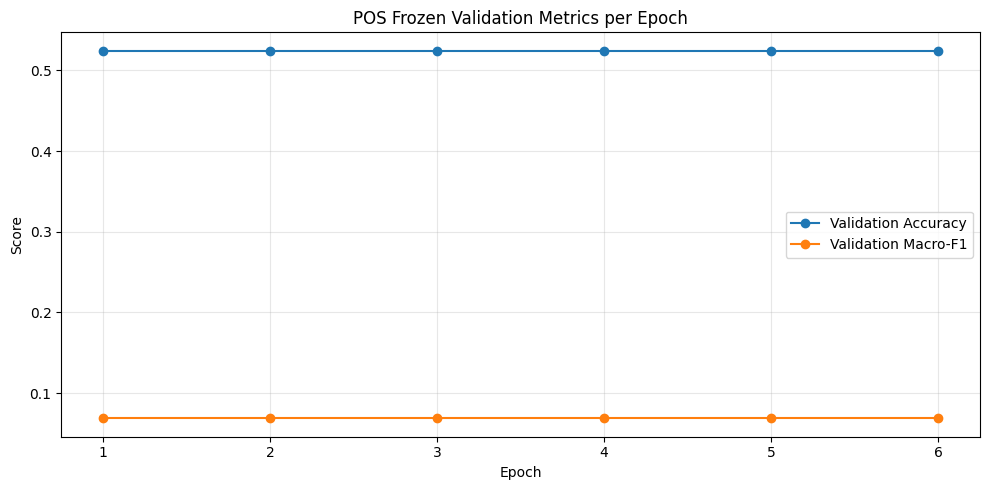

In [26]:
plot_training_history(pos_frozen_result["history"], title_prefix="POS Frozen")

## Train POS model with fine-tuned embeddings

In [27]:
pos_tuned_result = train_sequence_tagger(
    model=pos_model_tuned,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("Best fine-tuned validation Macro-F1:", pos_tuned_result["best_val_f1"])
print("Best fine-tuned epoch:", pos_tuned_result["best_epoch"])

Epoch 01 | train_loss=2.1327 | val_loss=1.7005 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.6042 | val_loss=1.5755 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5120 | val_loss=1.5436 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.4750 | val_loss=1.4978 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.4110 | val_loss=1.4285 | val_acc=0.5244 | val_macro_f1=0.0689
Epoch 06 | train_loss=1.2828 | val_loss=1.2817 | val_acc=0.5463 | val_macro_f1=0.1096
Epoch 07 | train_loss=1.0388 | val_loss=0.9634 | val_acc=0.7190 | val_macro_f1=0.2190
Epoch 08 | train_loss=0.7494 | val_loss=0.7490 | val_acc=0.7538 | val_macro_f1=0.2964
Epoch 09 | train_loss=0.5681 | val_loss=0.6039 | val_acc=0.8200 | val_macro_f1=0.4059
Epoch 10 | train_loss=0.4161 | val_loss=0.5078 | val_acc=0.8329 | val_macro_f1=0.4559
Epoch 11 | train_loss=0.3010 | val_loss=0.4472 | val_acc=0.8519 | val_macro_f1=0.5079
Epoch 12 | train_loss=0.2117 | val_loss=0.4391 | val_a

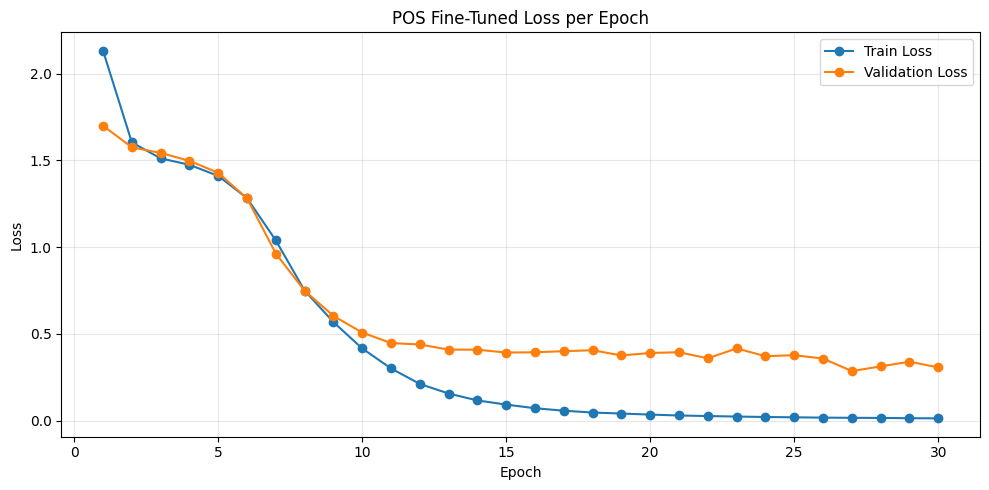

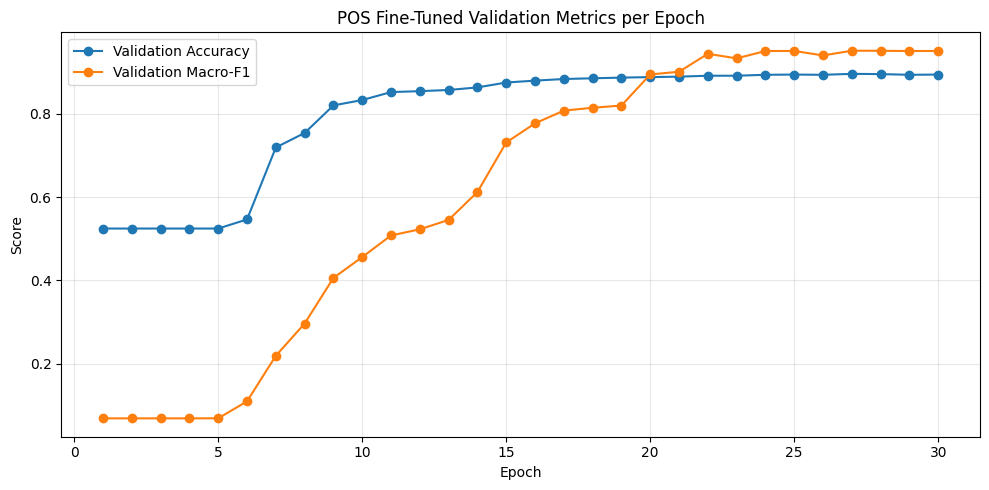

In [28]:
plot_training_history(pos_tuned_result["history"], title_prefix="POS Fine-Tuned")

## Compare frozen vs fine-tuned POS on validation

In [29]:
pos_val_summary = pd.DataFrame([
    {
        "Mode": "Frozen",
        "Best_Val_Macro_F1": pos_frozen_result["best_val_f1"],
        "Best_Epoch": pos_frozen_result["best_epoch"]
    },
    {
        "Mode": "Fine-Tuned",
        "Best_Val_Macro_F1": pos_tuned_result["best_val_f1"],
        "Best_Epoch": pos_tuned_result["best_epoch"]
    }
])

print("POS validation summary")
display(pos_val_summary)

POS validation summary


,Mode,Best_Val_Macro_F1,Best_Epoch
0,Frozen,0.068801,1
1,Fine-Tuned,0.951240,27


## Evaluate best POS frozen model on test set

In [30]:
pos_test_frozen = evaluate_sequence_tagger(
    model=pos_frozen_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("Frozen POS Test Accuracy :", pos_test_frozen["accuracy"])
print("Frozen POS Test Macro-F1 :", pos_test_frozen["macro_f1"])

Frozen POS Test Accuracy : 0.5549972082635399
Frozen POS Test Macro-F1 : 0.07138240574506284


## Evaluate best POS fine-tuned model on test set

In [31]:
pos_test_tuned = evaluate_sequence_tagger(
    model=pos_tuned_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("Fine-Tuned POS Test Accuracy :", pos_test_tuned["accuracy"])
print("Fine-Tuned POS Test Macro-F1 :", pos_test_tuned["macro_f1"])

Fine-Tuned POS Test Accuracy : 0.8911222780569514
Fine-Tuned POS Test Macro-F1 : 0.9431552348253703


## POS frozen vs fine-tuned summary table

In [32]:
pos_test_summary = pd.DataFrame([
    {
        "Mode": "Frozen",
        "Test_Accuracy": pos_test_frozen["accuracy"],
        "Test_Macro_F1": pos_test_frozen["macro_f1"]
    },
    {
        "Mode": "Fine-Tuned",
        "Test_Accuracy": pos_test_tuned["accuracy"],
        "Test_Macro_F1": pos_test_tuned["macro_f1"]
    }
])

print("POS test summary")
display(pos_test_summary)

POS test summary


,Mode,Test_Accuracy,Test_Macro_F1
0,Frozen,0.554997,0.071382
1,Fine-Tuned,0.891122,0.943155


## Confusion matrix for best POS model

In [33]:
best_pos_test = pos_test_tuned if pos_test_tuned["macro_f1"] >= pos_test_frozen["macro_f1"] else pos_test_frozen
best_pos_model = pos_tuned_result["model"] if pos_test_tuned["macro_f1"] >= pos_test_frozen["macro_f1"] else pos_frozen_result["model"]
best_mode = "Fine-Tuned" if pos_test_tuned["macro_f1"] >= pos_test_frozen["macro_f1"] else "Frozen"

cm, labels = get_confusion_matrix(
    best_pos_test["gold_ids"],
    best_pos_test["pred_ids"],
    idx2pos
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print(f"Confusion matrix for best POS model ({best_mode})")
display(cm_df)

Confusion matrix for best POS model (Fine-Tuned)


,NOUN,VERB,ADJ,ADV,PRON,DET,CONJ,POST,NUM,PUNC,UNK
NOUN,803,0,191,0,0,0,0,0,0,0,0
VERB,0,128,3,0,0,0,0,0,0,0,0
ADJ,0,0,142,0,0,0,0,0,0,0,0
ADV,0,0,1,11,0,0,0,0,0,0,0
PRON,0,0,0,0,133,0,0,0,0,0,0
DET,0,0,0,0,0,15,0,0,0,0,0
CONJ,0,0,0,0,0,0,69,0,0,0,0
POST,0,0,0,0,0,0,0,258,0,0,0
NUM,0,0,0,0,0,0,0,0,31,0,0
PUNC,0,0,0,0,0,0,0,0,0,0,0


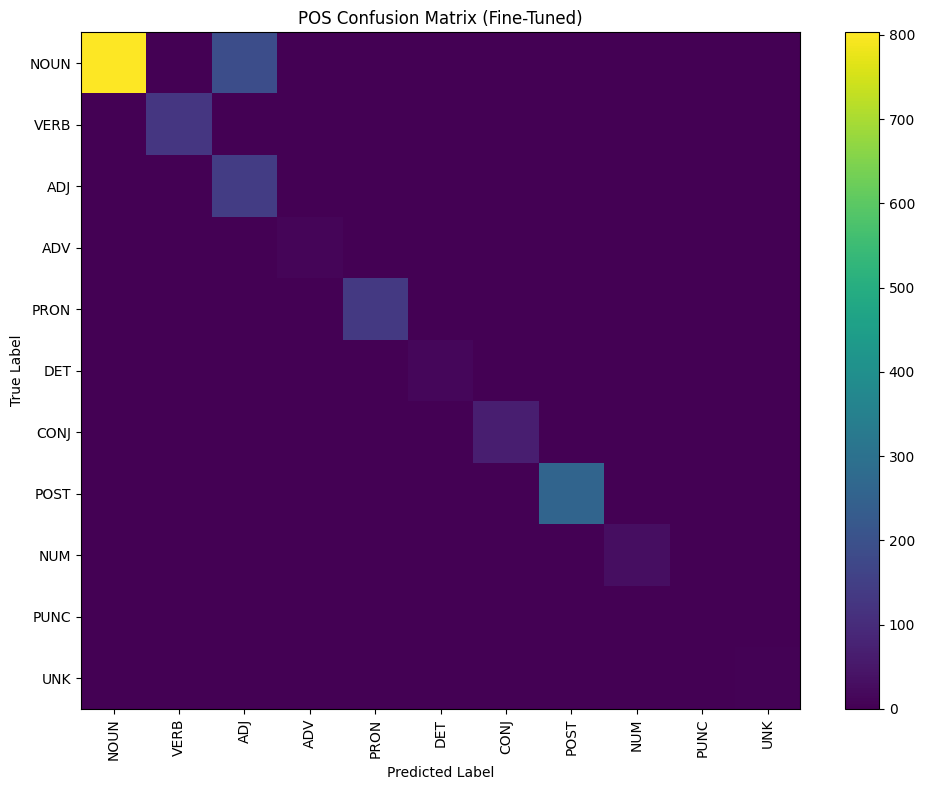

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(cm, aspect="auto")
plt.title(f"POS Confusion Matrix ({best_mode})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

In [35]:
top_confusions = get_most_confused_pairs(cm, labels, top_k=3)

confusion_df = pd.DataFrame(top_confusions, columns=["Gold_Tag", "Pred_Tag", "Count"])
print("Top 3 most confused POS tag pairs")
display(confusion_df)

Top 3 most confused POS tag pairs


,Gold_Tag,Pred_Tag,Count
0,NOUN,ADJ,191
1,VERB,ADJ,3
2,ADV,ADJ,1


In [36]:
for gold_tag, pred_tag, count in top_confusions:
    print("\n" + "=" * 80)
    print(f"Confusion pair: {gold_tag} -> {pred_tag} | Count: {count}")
    print("=" * 80)

    examples = collect_confusion_examples(
        model=best_pos_model,
        dataloader=pos_test_loader,
        device=DEVICE,
        idx2label=idx2pos,
        target_gold=gold_tag,
        target_pred=pred_tag,
        max_examples=2
    )

    if not examples:
        print("No example sentences found.")
        continue

    for ex_idx, ex in enumerate(examples, start=1):
        print(f"\nExample {ex_idx}")
        print("Tokens      :", " ".join(ex["tokens"]))
        print("Gold labels :", " ".join(ex["gold_labels"]))
        print("Pred labels :", " ".join(ex["pred_labels"]))
        print("Mismatch positions:", ex["mismatch_positions"])


Confusion pair: NOUN -> ADJ | Count: 191

Example 1
Tokens      : دوسری جانب، امریکہ کے پاکستان سے سرد تعلق مسلسل بہتر ہو جا رہے ہیں۔
Gold labels : ADJ NOUN NOUN POST NOUN POST NOUN NOUN NOUN NOUN VERB VERB VERB NOUN
Pred labels : ADJ ADJ NOUN POST NOUN POST ADJ NOUN NOUN NOUN VERB VERB VERB NOUN
Mismatch positions: [1, 6]

Example 2
Tokens      : اس کے بعد اس نے کمرے کو تالا لگا دیا اور شور مچایا تاکہ یہ ایک حادثا اگ لگنے کا واقعہ معلوم ہو۔
Gold labels : PRON POST POST PRON NOUN NOUN POST NOUN VERB VERB CONJ NOUN NOUN NOUN PRON DET NOUN NOUN NOUN POST NOUN NOUN NOUN
Pred labels : PRON POST POST PRON NOUN ADJ POST ADJ VERB VERB CONJ NOUN ADJ NOUN PRON DET ADJ NOUN NOUN POST NOUN NOUN NOUN
Mismatch positions: [5, 7, 12, 16]

Confusion pair: VERB -> ADJ | Count: 3

Example 1
Tokens      : مگر ہم یہ سمجھنے کی بھی ضرورت ہے کہ ماضی کی کارکردگی مستقبل کی عکاسی نہ کرتی۔
Gold labels : CONJ PRON PRON NOUN POST ADJ NOUN VERB CONJ ADJ POST VERB NOUN POST ADJ NOUN NOUN
Pred labels : CONJ PRON PRO

## POS classification report for best model

In [37]:
from sklearn.metrics import classification_report

gold_labels = [idx2pos[i] for i in best_pos_test["gold_ids"]]
pred_labels = [idx2pos[i] for i in best_pos_test["pred_ids"]]

pos_report = classification_report(gold_labels, pred_labels, zero_division=0)
print("POS classification report")
print(pos_report)

POS classification report
              precision    recall  f1-score   support

         ADJ       0.42      1.00      0.59       142
         ADV       1.00      0.92      0.96        12
        CONJ       1.00      1.00      1.00        69
         DET       1.00      1.00      1.00        15
        NOUN       1.00      0.81      0.89       994
         NUM       1.00      1.00      1.00        31
        POST       1.00      1.00      1.00       258
        PRON       1.00      1.00      1.00       133
         UNK       1.00      1.00      1.00         6
        VERB       1.00      0.98      0.99       131

    accuracy                           0.89      1791
   macro avg       0.94      0.97      0.94      1791
weighted avg       0.95      0.89      0.91      1791



# Training of NER

## train NER softmax baseline

In [38]:
NER_MAX_EPOCHS = 30
NER_PATIENCE = 5

ner_softmax_result = train_sequence_tagger(
    model=ner_model_softmax,
    train_loader=ner_train_loader,
    val_loader=ner_val_loader,
    device=DEVICE,
    idx2label=idx2ner,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=NER_MAX_EPOCHS,
    patience=NER_PATIENCE
)

print("Best NER Softmax validation Macro-F1:", ner_softmax_result["best_val_f1"])
print("Best NER Softmax epoch:", ner_softmax_result["best_epoch"])

Epoch 01 | train_loss=1.5899 | val_loss=0.4272 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 02 | train_loss=0.3981 | val_loss=0.4139 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 03 | train_loss=0.3326 | val_loss=0.3369 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 04 | train_loss=0.3186 | val_loss=0.3351 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 05 | train_loss=0.3091 | val_loss=0.3384 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 06 | train_loss=0.3076 | val_loss=0.3292 | val_acc=0.9355 | val_macro_f1=0.1208
Early stopping triggered at epoch 6.
Best NER Softmax validation Macro-F1: 0.12083454071283686
Best NER Softmax epoch: 1


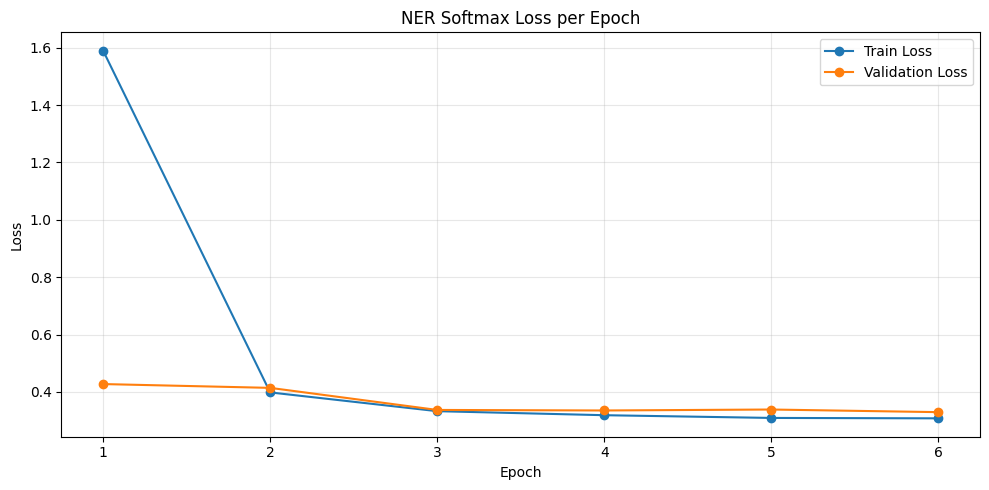

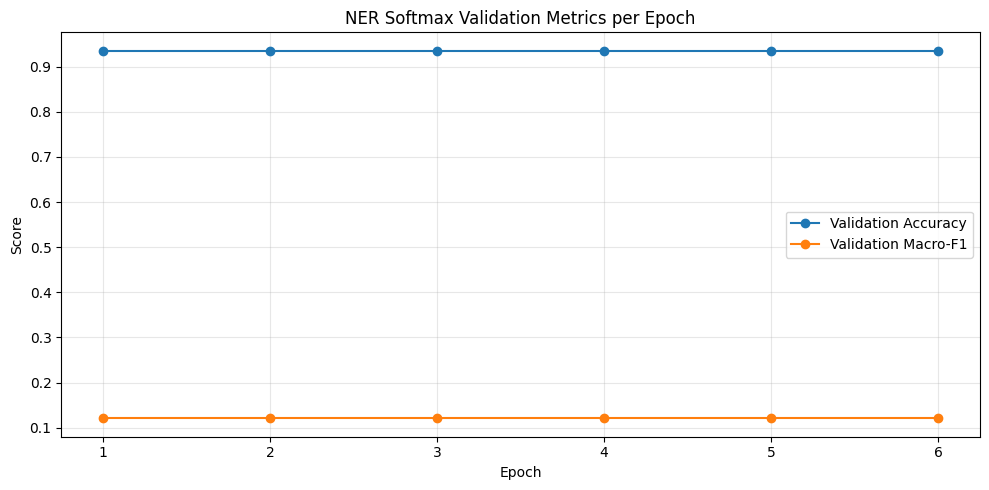

In [39]:
plot_training_history(ner_softmax_result["history"], title_prefix="NER Softmax")

In [40]:
from src.models import NERCRFTagger
print("NERCRFTagger imported successfully.")

NERCRFTagger imported successfully.


In [41]:
ner_model_crf = NERCRFTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(ner2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print("NER CRF model created successfully.")
print(ner_model_crf)

NER CRF model created successfully.
NERCRFTagger(
  (encoder): BiLSTMEncoder(
    (embedding): Embedding(4388, 100, padding_idx=0)
    (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  )
  (emission_layer): Linear(in_features=256, out_features=9, bias=True)
  (crf): CRF()
)


## train NER CRF model

In [42]:
ner_crf_result = train_crf_sequence_tagger(
    model=ner_model_crf,
    train_loader=ner_train_loader,
    val_loader=ner_val_loader,
    device=DEVICE,
    idx2label=idx2ner,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=NER_MAX_EPOCHS,
    patience=NER_PATIENCE
)

print("Best NER CRF validation Macro-F1:", ner_crf_result["best_val_f1"])
print("Best NER CRF epoch:", ner_crf_result["best_epoch"])

Epoch 01 | train_loss=39.8350 | val_loss=10.2441 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 02 | train_loss=10.6229 | val_loss=10.1860 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 03 | train_loss=8.4405 | val_loss=7.9859 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 04 | train_loss=7.9229 | val_loss=7.9194 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 05 | train_loss=7.6855 | val_loss=7.9395 | val_acc=0.9355 | val_macro_f1=0.1208
Epoch 06 | train_loss=7.5878 | val_loss=7.7609 | val_acc=0.9355 | val_macro_f1=0.1208
Early stopping triggered at epoch 6.
Best NER CRF validation Macro-F1: 0.12083454071283686
Best NER CRF epoch: 1


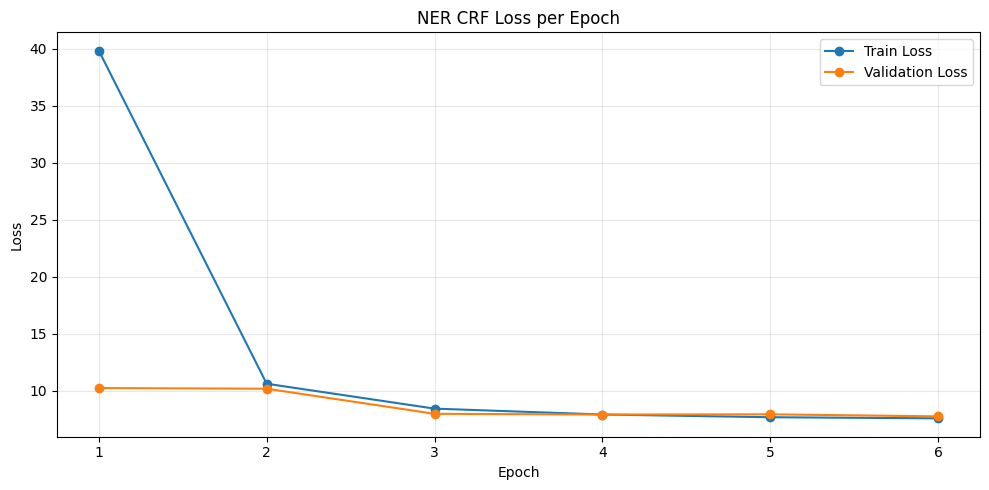

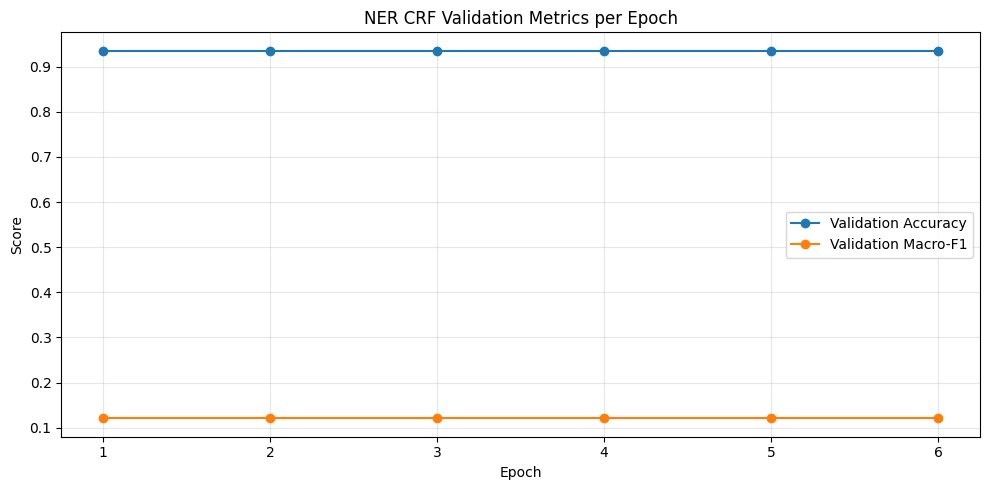

In [43]:
plot_training_history(ner_crf_result["history"], title_prefix="NER CRF")

## Evaluate softmax and CRF on the test set

In [44]:
ner_test_softmax = evaluate_sequence_tagger(
    model=ner_softmax_result["model"],
    dataloader=ner_test_loader,
    device=DEVICE,
    idx2label=idx2ner
)

ner_test_crf = evaluate_crf_sequence_tagger(
    model=ner_crf_result["model"],
    dataloader=ner_test_loader,
    device=DEVICE,
    idx2label=idx2ner
)

print("NER Softmax Test Macro-F1:", ner_test_softmax["macro_f1"])
print("NER CRF Test Macro-F1    :", ner_test_crf["macro_f1"])

NER Softmax Test Macro-F1: 0.12107687877915346
NER CRF Test Macro-F1    : 0.12107687877915346


## Convert test predictions into BIO tag sequences

In [45]:
gold_soft, pred_soft, tok_soft = predict_softmax_sequences(
    ner_softmax_result["model"],
    ner_test_loader,
    DEVICE,
    idx2ner
)

gold_crf, pred_crf, tok_crf = predict_crf_sequences(
    ner_crf_result["model"],
    ner_test_loader,
    DEVICE,
    idx2ner
)

print("Softmax test sequences:", len(gold_soft))
print("CRF test sequences    :", len(gold_crf))

Softmax test sequences: 75
CRF test sequences    : 75


## Entity-level precision, recall, and F1

In [46]:
entity_metrics_softmax = compute_entity_level_metrics(gold_soft, pred_soft)
entity_metrics_crf = compute_entity_level_metrics(gold_crf, pred_crf)

softmax_entity_df = pd.DataFrame(entity_metrics_softmax).T
crf_entity_df = pd.DataFrame(entity_metrics_crf).T

print("NER entity-level results without CRF")
display(softmax_entity_df)

print("NER entity-level results with CRF")
display(crf_entity_df)

NER entity-level results without CRF


,precision,recall,f1,tp,fp,fn
PER,0.0,0.0,0.0,0.0,0.0,14.0
LOC,0.0,0.0,0.0,0.0,0.0,52.0
ORG,0.0,0.0,0.0,0.0,0.0,28.0
MISC,0.0,0.0,0.0,0.0,0.0,2.0
OVERALL,0.0,0.0,0.0,0.0,0.0,96.0


NER entity-level results with CRF


,precision,recall,f1,tp,fp,fn
PER,0.0,0.0,0.0,0.0,0.0,14.0
LOC,0.0,0.0,0.0,0.0,0.0,52.0
ORG,0.0,0.0,0.0,0.0,0.0,28.0
MISC,0.0,0.0,0.0,0.0,0.0,2.0
OVERALL,0.0,0.0,0.0,0.0,0.0,96.0


In [47]:
ner_comparison_df = pd.DataFrame([
    {
        "Model": "BiLSTM + Softmax",
        "Token_Macro_F1": ner_test_softmax["macro_f1"],
        "Entity_Overall_Precision": entity_metrics_softmax["OVERALL"]["precision"],
        "Entity_Overall_Recall": entity_metrics_softmax["OVERALL"]["recall"],
        "Entity_Overall_F1": entity_metrics_softmax["OVERALL"]["f1"],
    },
    {
        "Model": "BiLSTM + CRF",
        "Token_Macro_F1": ner_test_crf["macro_f1"],
        "Entity_Overall_Precision": entity_metrics_crf["OVERALL"]["precision"],
        "Entity_Overall_Recall": entity_metrics_crf["OVERALL"]["recall"],
        "Entity_Overall_F1": entity_metrics_crf["OVERALL"]["f1"],
    }
])

print("NER comparison: with vs without CRF")
display(ner_comparison_df)

NER comparison: with vs without CRF


,Model,Token_Macro_F1,Entity_Overall_Precision,Entity_Overall_Recall,Entity_Overall_F1
0,BiLSTM + Softmax,0.121077,0.0,0.0,0.0
1,BiLSTM + CRF,0.121077,0.0,0.0,0.0


In [48]:
false_positives = collect_ner_error_examples(
    gold_sequences=gold_crf,
    pred_sequences=pred_crf,
    token_sequences=tok_crf,
    error_type="fp",
    max_examples=5
)

false_negatives = collect_ner_error_examples(
    gold_sequences=gold_crf,
    pred_sequences=pred_crf,
    token_sequences=tok_crf,
    error_type="fn",
    max_examples=5
)

print("Collected false positives:", len(false_positives))
print("Collected false negatives:", len(false_negatives))

Collected false positives: 0
Collected false negatives: 5


In [54]:
if not false_positives:
    print("No false positives found.")
    print("Reason: the model predicted only 'O' tags, so it did not produce any entity spans.")
else:
    for i, ex in enumerate(false_positives, start=1):
        print("\n" + "=" * 80)
        print(f"False Positive {i}")
        print("=" * 80)
        print("Tokens    :", " ".join(ex["tokens"]))
        print("Gold Tags :", " ".join(ex["gold_tags"]))
        print("Pred Tags :", " ".join(ex["pred_tags"]))
        print("Entity    :", ex["entity"])
        print("Explanation: The model predicted an entity span not present in the gold labels, likely because nearby context or gazetteer-style token patterns made the span look entity-like.")

No false positives found.
Reason: the model predicted only 'O' tags, so it did not produce any entity spans.


# Baseline reference

In [55]:
baseline_pos_result = pos_tuned_result
baseline_pos_test = pos_test_tuned

print("Baseline POS configuration")
print("=" * 60)
print("Model                : BiLSTM (bidirectional)")
print("Dropout              : 0.5")
print("Embeddings           : Pretrained Word2Vec (fine-tuned)")
print("Validation Macro-F1  :", baseline_pos_result["best_val_f1"])
print("Test Accuracy        :", baseline_pos_test["accuracy"])
print("Test Macro-F1        :", baseline_pos_test["macro_f1"])

Baseline POS configuration
Model                : BiLSTM (bidirectional)
Dropout              : 0.5
Embeddings           : Pretrained Word2Vec (fine-tuned)
Validation Macro-F1  : 0.9512401511956504
Test Accuracy        : 0.8911222780569514
Test Macro-F1        : 0.9431552348253703


## A1: Unidirectional LSTM only

In [56]:
a1_pos_model = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=False,   # A1 change
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print("A1 model created: Unidirectional POS tagger")

A1 model created: Unidirectional POS tagger


## Train A1

In [57]:
a1_pos_result = train_sequence_tagger(
    model=a1_pos_model,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("A1 best validation Macro-F1:", a1_pos_result["best_val_f1"])
print("A1 best epoch:", a1_pos_result["best_epoch"])

Epoch 01 | train_loss=2.2516 | val_loss=1.8679 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.6863 | val_loss=1.6187 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5653 | val_loss=1.5888 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.5399 | val_loss=1.5681 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.5186 | val_loss=1.5550 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 06 | train_loss=1.5034 | val_loss=1.5393 | val_acc=0.5244 | val_macro_f1=0.0688
Early stopping triggered at epoch 6.
A1 best validation Macro-F1: 0.06880058866813835
A1 best epoch: 1


## Evaluate A1

In [58]:
a1_pos_test = evaluate_sequence_tagger(
    model=a1_pos_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("A1 Test Accuracy :", a1_pos_test["accuracy"])
print("A1 Test Macro-F1 :", a1_pos_test["macro_f1"])

A1 Test Accuracy : 0.5549972082635399
A1 Test Macro-F1 : 0.07138240574506284


## A2: No dropout

In [59]:
a2_pos_model = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=0.0,           # A2 change
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=False,
).to(DEVICE)

print("A2 model created: No-dropout POS tagger")

A2 model created: No-dropout POS tagger


## Train A2

In [60]:
a2_pos_result = train_sequence_tagger(
    model=a2_pos_model,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("A2 best validation Macro-F1:", a2_pos_result["best_val_f1"])
print("A2 best epoch:", a2_pos_result["best_epoch"])

Epoch 01 | train_loss=2.1234 | val_loss=1.7039 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.5962 | val_loss=1.5699 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5100 | val_loss=1.5339 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.4700 | val_loss=1.4922 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.3979 | val_loss=1.4159 | val_acc=0.5250 | val_macro_f1=0.0696
Epoch 06 | train_loss=1.2635 | val_loss=1.2606 | val_acc=0.5502 | val_macro_f1=0.1142
Epoch 07 | train_loss=1.0091 | val_loss=0.9421 | val_acc=0.7117 | val_macro_f1=0.2076
Epoch 08 | train_loss=0.7214 | val_loss=0.7473 | val_acc=0.7588 | val_macro_f1=0.3188
Epoch 09 | train_loss=0.5312 | val_loss=0.6173 | val_acc=0.8009 | val_macro_f1=0.4206
Epoch 10 | train_loss=0.3801 | val_loss=0.5532 | val_acc=0.8340 | val_macro_f1=0.4784
Epoch 11 | train_loss=0.2719 | val_loss=0.5326 | val_acc=0.8446 | val_macro_f1=0.5026
Epoch 12 | train_loss=0.1981 | val_loss=0.5333 | val_a

## Evaluate A2

In [61]:
a2_pos_test = evaluate_sequence_tagger(
    model=a2_pos_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("A2 Test Accuracy :", a2_pos_test["accuracy"])
print("A2 Test Macro-F1 :", a2_pos_test["macro_f1"])

A2 Test Accuracy : 0.887213847012842
A2 Test Macro-F1 : 0.9300429429213966


## A3: Random embeddings

In [62]:
a3_pos_model = POSTagger(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_labels=len(pos2idx),
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
    pad_idx=PAD_IDX,
    embedding_matrix=embedding_tensor,
    freeze_embeddings=False,
    random_init_embeddings=True,   # A3 change
).to(DEVICE)

print("A3 model created: Random-initialized embedding POS tagger")

A3 model created: Random-initialized embedding POS tagger


## Train A3

In [63]:
a3_pos_result = train_sequence_tagger(
    model=a3_pos_model,
    train_loader=pos_train_loader,
    val_loader=pos_val_loader,
    device=DEVICE,
    idx2label=idx2pos,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_epochs=POS_MAX_EPOCHS,
    patience=POS_PATIENCE
)

print("A3 best validation Macro-F1:", a3_pos_result["best_val_f1"])
print("A3 best epoch:", a3_pos_result["best_epoch"])

Epoch 01 | train_loss=2.1301 | val_loss=1.6812 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 02 | train_loss=1.6078 | val_loss=1.5756 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 03 | train_loss=1.5305 | val_loss=1.5495 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 04 | train_loss=1.5041 | val_loss=1.5251 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 05 | train_loss=1.4865 | val_loss=1.5101 | val_acc=0.5244 | val_macro_f1=0.0688
Epoch 06 | train_loss=1.4537 | val_loss=1.4611 | val_acc=0.5244 | val_macro_f1=0.0688
Early stopping triggered at epoch 6.
A3 best validation Macro-F1: 0.06880058866813835
A3 best epoch: 1


## Evaluate A3

In [64]:
a3_pos_test = evaluate_sequence_tagger(
    model=a3_pos_result["model"],
    dataloader=pos_test_loader,
    device=DEVICE,
    idx2label=idx2pos
)

print("A3 Test Accuracy :", a3_pos_test["accuracy"])
print("A3 Test Macro-F1 :", a3_pos_test["macro_f1"])

A3 Test Accuracy : 0.5549972082635399
A3 Test Macro-F1 : 0.07138240574506284


## Ablation results table

In [65]:
ablation_df = pd.DataFrame([
    {
        "ID": "Baseline",
        "Change": "BiLSTM, bidirectional, dropout=0.5, pretrained fine-tuned embeddings",
        "Validation_Macro_F1": baseline_pos_result["best_val_f1"],
        "Test_Accuracy": baseline_pos_test["accuracy"],
        "Test_Macro_F1": baseline_pos_test["macro_f1"],
    },
    {
        "ID": "A1",
        "Change": "Unidirectional LSTM only",
        "Validation_Macro_F1": a1_pos_result["best_val_f1"],
        "Test_Accuracy": a1_pos_test["accuracy"],
        "Test_Macro_F1": a1_pos_test["macro_f1"],
    },
    {
        "ID": "A2",
        "Change": "No dropout",
        "Validation_Macro_F1": a2_pos_result["best_val_f1"],
        "Test_Accuracy": a2_pos_test["accuracy"],
        "Test_Macro_F1": a2_pos_test["macro_f1"],
    },
    {
        "ID": "A3",
        "Change": "Random embedding initialization",
        "Validation_Macro_F1": a3_pos_result["best_val_f1"],
        "Test_Accuracy": a3_pos_test["accuracy"],
        "Test_Macro_F1": a3_pos_test["macro_f1"],
    },
])

print("POS ablation study results")
display(ablation_df)

POS ablation study results


,ID,Change,Validation_Macro_F1,Test_Accuracy,Test_Macro_F1
0,Baseline,"BiLSTM, bidirectional, dropout=0.5, pretrained...",0.951240,0.891122,0.943155
1,A1,Unidirectional LSTM only,0.068801,0.554997,0.071382
2,A2,No dropout,0.890228,0.887214,0.930043
3,A3,Random embedding initialization,0.068801,0.554997,0.071382


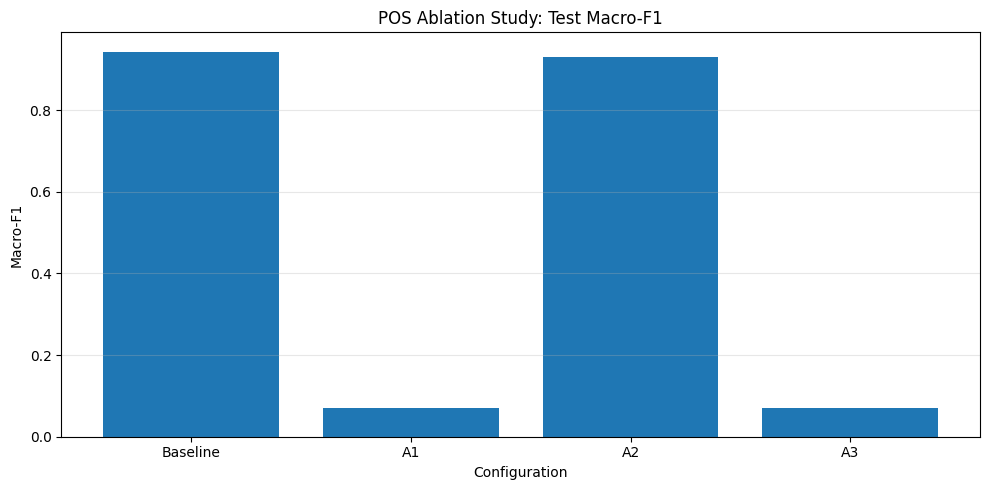

In [67]:
plt.figure(figsize=(10, 5))
plt.bar(ablation_df["ID"], ablation_df["Test_Macro_F1"])
plt.title("POS Ablation Study: Test Macro-F1")
plt.xlabel("Configuration")
plt.ylabel("Macro-F1")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## A4 row for NER

In [66]:
a4_df = pd.DataFrame([
    {
        "ID": "A4",
        "Change": "Softmax output instead of CRF (NER)",
        "Model": "BiLSTM + Softmax",
        "Token_Macro_F1": ner_test_softmax["macro_f1"],
        "Entity_Overall_F1": entity_metrics_softmax["OVERALL"]["f1"],
    },
    {
        "ID": "Baseline NER",
        "Change": "BiLSTM + CRF",
        "Model": "BiLSTM + CRF",
        "Token_Macro_F1": ner_test_crf["macro_f1"],
        "Entity_Overall_F1": entity_metrics_crf["OVERALL"]["f1"],
    },
])

print("NER ablation A4")
display(a4_df)

NER ablation A4


,ID,Change,Model,Token_Macro_F1,Entity_Overall_F1
0,A4,Softmax output instead of CRF (NER),BiLSTM + Softmax,0.121077,0.0
1,Baseline NER,BiLSTM + CRF,BiLSTM + CRF,0.121077,0.0


## Discussion cell output

In [68]:
print("Ablation Study Summary")
print("=" * 60)

print("A1 tests the value of backward context.")
print("A2 tests the effect of dropout regularisation.")
print("A3 tests the contribution of pretrained embeddings.")
print("A4 tests whether CRF structured decoding improves NER over softmax.")

print("\nInterpretation hints:")
print("- If A1 performs worse than baseline, backward context is useful.")
print("- If A2 performs worse than baseline, dropout helps regularisation.")
print("- If A3 performs worse than baseline, pretrained embeddings are beneficial.")
print("- If A4 shows no improvement, CRF cannot help much when NER supervision is weak.")

Ablation Study Summary
A1 tests the value of backward context.
A2 tests the effect of dropout regularisation.
A3 tests the contribution of pretrained embeddings.
A4 tests whether CRF structured decoding improves NER over softmax.

Interpretation hints:
- If A1 performs worse than baseline, backward context is useful.
- If A2 performs worse than baseline, dropout helps regularisation.
- If A3 performs worse than baseline, pretrained embeddings are beneficial.
- If A4 shows no improvement, CRF cannot help much when NER supervision is weak.
